In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
df = pd.read_csv(r"C:\Users\Priyanshu Kumar\Desktop\Student Burnout & Acedemic Risk Prediction System\data\raw\student_burnout_dataset_350.csv")

In [4]:
df = df.drop(["student_id"], axis= 1)

X = df.drop(["burnout_level", "burnout_score"], axis=1)
y = df["burnout_level"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [16]:
results = []

for name, model in models.items():

    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    macro_f1 = f1_score(y_test, y_test_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Train Accuracy,Test Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.971429,0.914286,0.878658,0.913053
2,SVM,0.960714,0.885714,0.822222,0.875810
4,Naive Bayes,0.846429,0.828571,0.739316,0.809890
1,Random Forest,1.000000,0.785714,0.686750,0.762283
3,KNN,0.817857,0.757143,0.635460,0.734397


In [18]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model based on Macro F1:", best_model_name)

Best Model based on Macro F1: Logistic Regression


Class Distribution Analysis

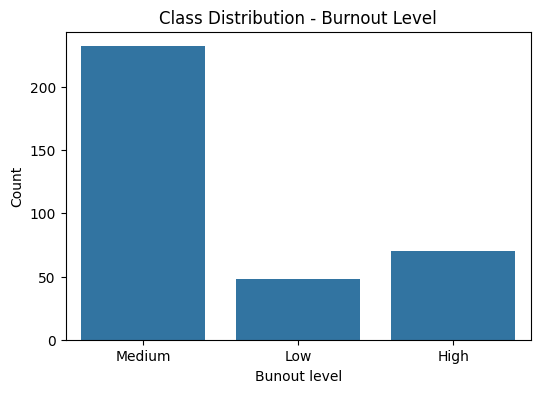

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution - Burnout Level")
plt.xlabel("Bunout level")
plt.ylabel("Count")
plt.show()

Correlation Analysis

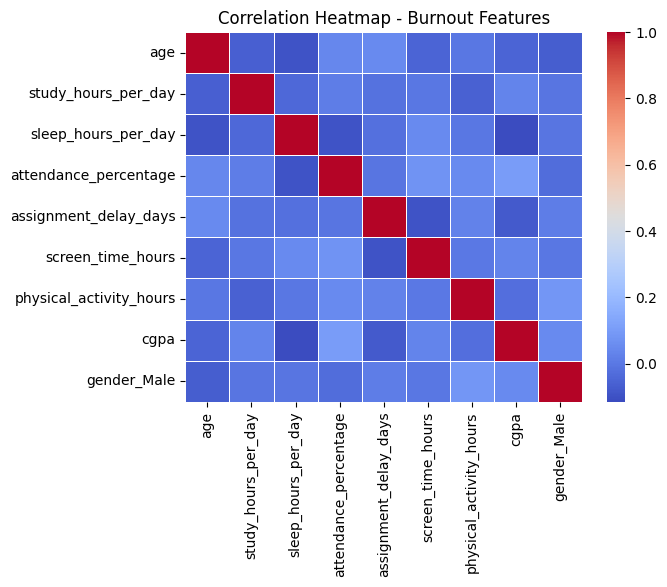

In [20]:
plt.Figure(figsize=(10,7))
sns.heatmap(X.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Burnout Features")
plt.show()

Feature Importance Analysis

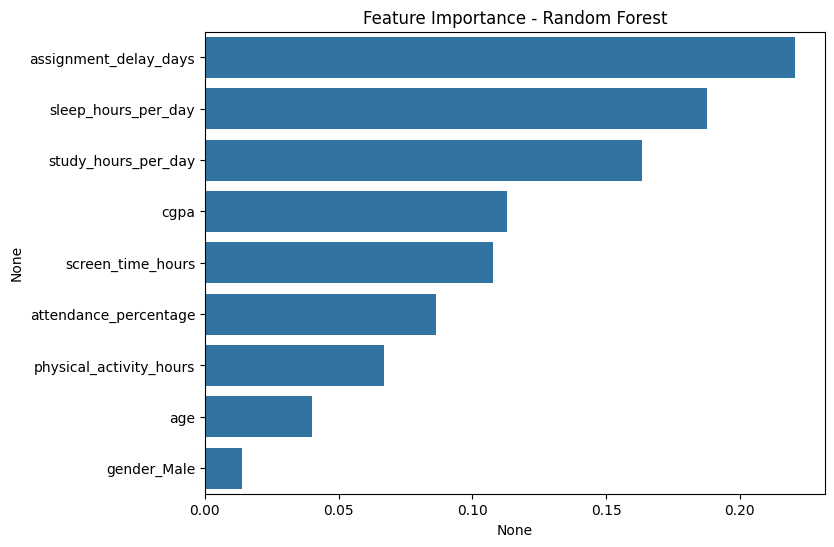

In [21]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.show()

Overfitting Check

In [22]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.7857142857142857


Random Forest initially overfit the training data (100% train accuracy vs lower test accuracy). After hyperparameter tuning, generalization improved but Logistic Regression still outperformed all models based on Macro F1 score.